In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Advertising dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [2]:
# Check the dataset shape
print("Dataset Shape:", df.shape)

# Check the data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (200, 5)

Data Types:
Unnamed: 0      int64
TV            float64
radio         float64
newspaper     float64
sales         float64
dtype: object

Missing Values:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64


In [3]:
# Display descriptive statistics
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


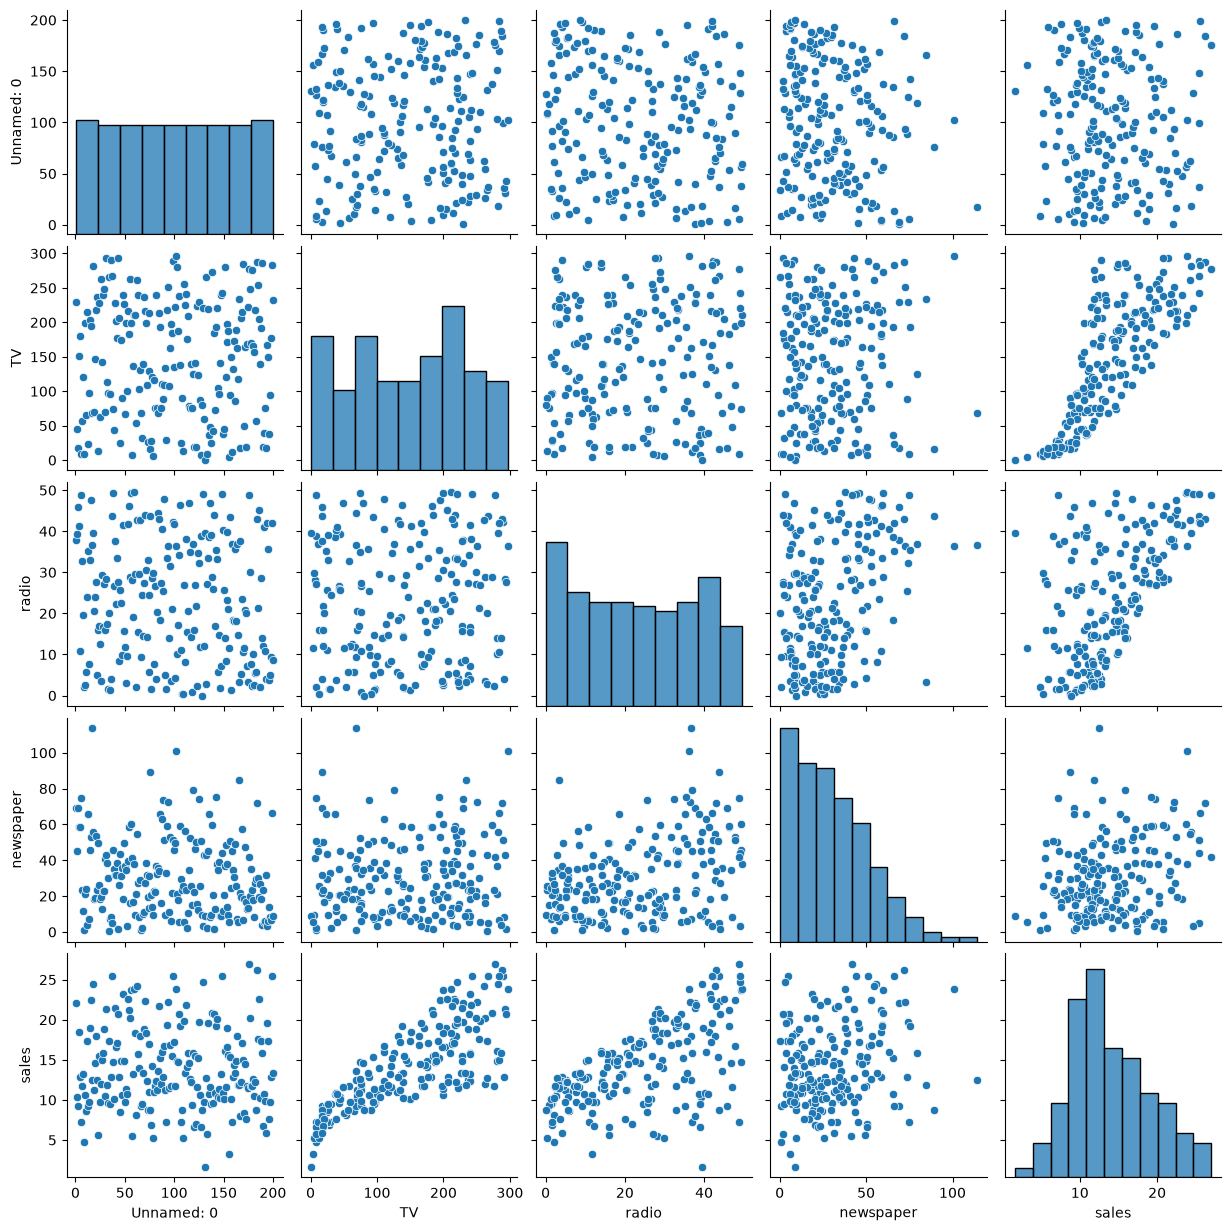

In [4]:
# Pairplot to visualize relationships between variables

sns.pairplot(df)

plt.show()

In [5]:
# Sales vs TV advertising spend

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

ValueError: Could not interpret value `Sales` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']


In [7]:
# Remove the unnecessary index column
df = df.drop("Unnamed: 0", axis=1)

# Display the remaining columns
print(df.columns.tolist())

['TV', 'radio', 'newspaper', 'sales']


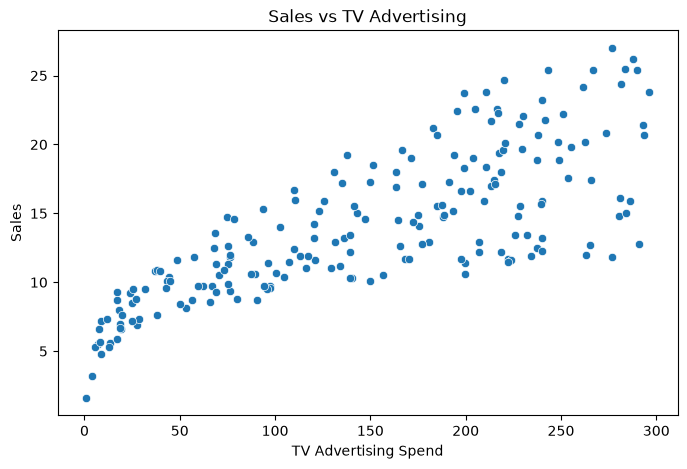

In [8]:
# Sales vs TV advertising spend

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="sales"
)

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

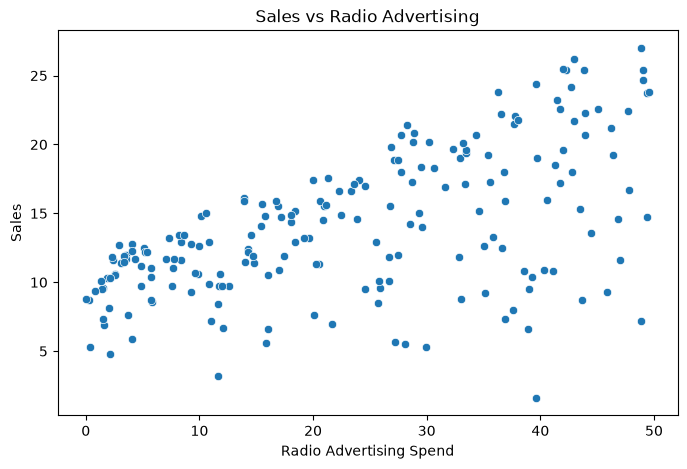

In [9]:
# Sales vs Radio advertising spend

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="radio",
    y="sales"
)

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

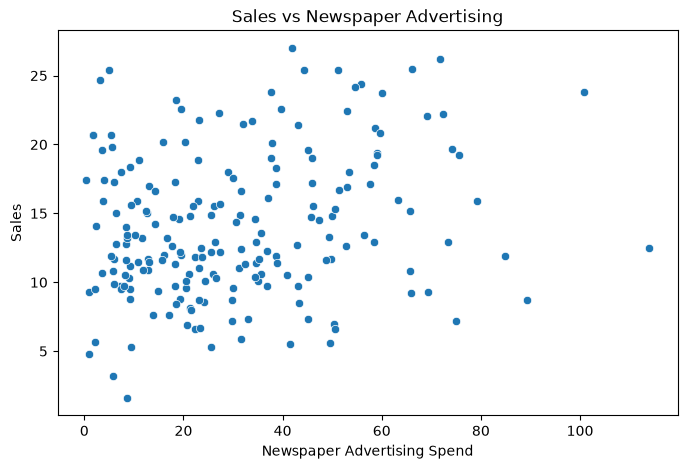

In [10]:
# Sales vs Newspaper advertising spend

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="newspaper",
    y="sales"
)

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

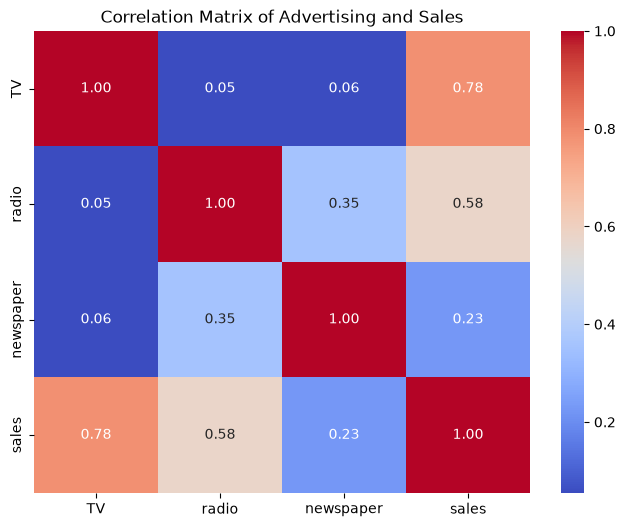

In [11]:
# Correlation matrix

correlation = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Advertising and Sales")

plt.show()

In [12]:
# Separate features and target

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
      TV  radio  newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64


In [13]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [14]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [15]:
# Make predictions using Linear Regression

y_pred_linear = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_linear[:10])

First 10 predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [16]:
# Evaluate Linear Regression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


In [17]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [18]:
# Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_rf[:10])

First 10 predictions:
[17.698 21.804 20.619  6.793 22.927 13.379 22.376  9.688 11.826 15.54 ]


In [19]:
# Evaluate Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 0.6203249999999988
RMSE: 0.7687170968568338
R²  : 0.9812782416450916


In [20]:
# Compare model performance

print("Model Comparison")
print("================")

print("\nLinear Regression:")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nRandom Forest:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

# Select the model with lower RMSE
if rmse_linear < rmse_rf:
    print("\nLinear Regression performed better based on RMSE.")
else:
    print("\nRandom Forest performed better based on RMSE.")

Model Comparison

Linear Regression:
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912

Random Forest:
MAE : 0.6203249999999988
RMSE: 0.7687170968568338
R²  : 0.9812782416450916

Random Forest performed better based on RMSE.


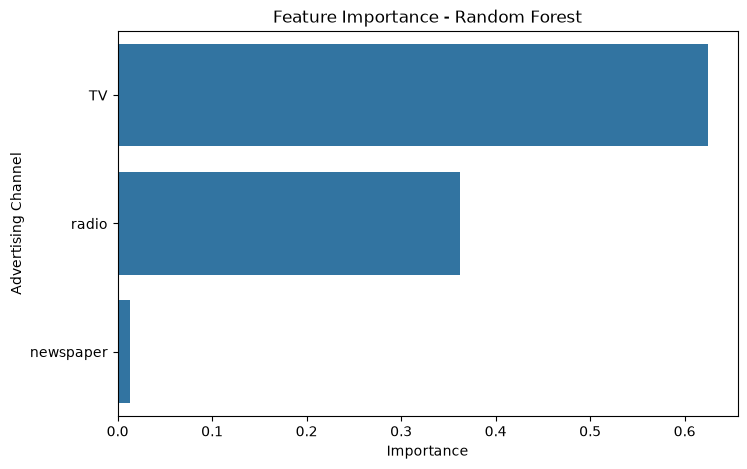

In [21]:
# Feature importance from Random Forest

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

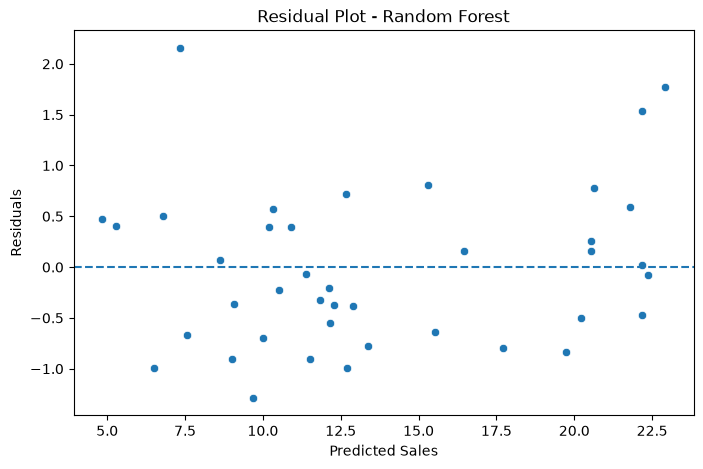

Best Model: Random Forest


In [22]:
# Select the best model based on RMSE
if rmse_linear < rmse_rf:
    best_predictions = y_pred_linear
    best_model_name = "Linear Regression"
else:
    best_predictions = y_pred_rf
    best_model_name = "Random Forest"

# Calculate residuals
residuals = y_test - best_predictions

# Plot residuals
plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions, y=residuals)
plt.axhline(y=0, linestyle="--")
plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

print("Best Model:", best_model_name)

## Conclusion

The Sales Prediction project analyzes the relationship between advertising expenditure and product sales using the TV, radio, and newspaper advertising channels. Exploratory data analysis and correlation analysis were used to understand the dataset and identify relationships between advertising and sales.

Linear Regression and Random Forest Regression were trained to predict sales. The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The feature importance analysis shows that TV advertising has the highest importance, followed by radio, while newspaper has much lower importance in predicting sales.

Overall, machine learning can be used to estimate sales based on advertising expenditure and provide useful insights for understanding the relationship between advertising channels and sales.